In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data/cleaned_food_delivery_data.csv")
df.head()

,Order_ID,Customer_ID,Customer_Age,Customer_Gender,City,Area,Restaurant_ID,Restaurant_Name,Cuisine_Type,Order_Date,...,Delivery_Partner_ID,Delivery_Rating,Restaurant_Rating,Order_Day,Peak_Hour,Profit_Margin,Profit_Margin_Percentage,Delivery_Performance,Customer_Age_Group,Day_of_Week
0,ORD000001,CUST6948,19.0,Male,Unknown,Central,RES936,Restaurant_29,Chinese,2024-10-20,...,DP563,5.0,4.4,Weekend,Peak Hour,0.13,13.0,Slow,Young Adult,Sunday
1,ORD000002,CUST6515,39.0,Female,Chennai,North,RES689,Restaurant_419,Chinese,2024-08-12,...,DP369,5.0,4.7,Weekday,Peak Hour,0.48,48.0,Fast,Middle Age,Monday
2,ORD000003,CUST1765,39.0,Male,Delhi,Unknown,RES723,Restaurant_244,Arabian,2024-12-08,...,DP580,4.0,4.9,Weekend,Peak Hour,0.08,8.0,Slow,Middle Age,Sunday
3,ORD000004,CUST2744,39.0,Male,Mumbai,Central,RES951,Restaurant_178,Chinese,2024-10-08,...,DP155,NaN,3.4,Weekday,Unknown,0.04,4.0,Moderate,Middle Age,Tuesday
4,ORD000005,CUST4389,57.0,Female,Chennai,South,RES419,Restaurant_262,Chinese,2024-02-04,...,DP728,2.0,4.4,Weekend,Non-Peak Hour,0.12,12.0,Fast,Senior,Sunday


In [3]:
#Distribution of Order Value and Delivery Time
df[["Order_Value","Delivery_Time_Min"]].describe()

,Order_Value,Delivery_Time_Min
count,100000.00000,100000.000000
mean,1786.94279,124.982030
std,1335.39821,74.211956
min,150.00000,20.000000
25%,935.00000,58.000000
50%,1197.00000,120.000000
75%,2743.00000,165.000000
max,5000.00000,300.000000


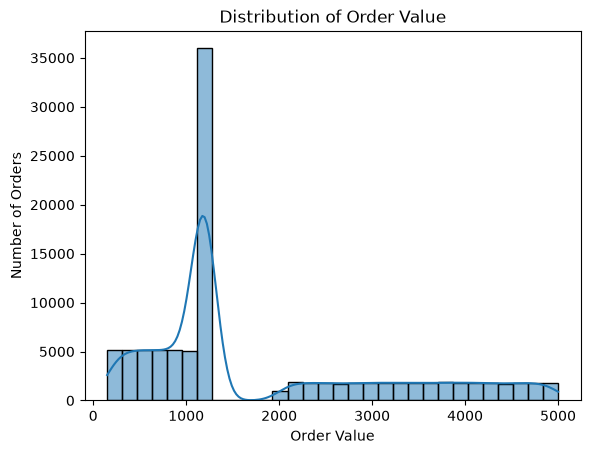

In [4]:
sns.histplot(df["Order_Value"], bins=30, kde=True)

plt.title("Distribution of Order Value")
plt.xlabel("Order Value")
plt.ylabel("Number of Orders")

plt.show()

### Order Value Distribution
- Most orders are low to medium priced: Most orders are between 150 and 1,200, with a large number of orders around 1,200.
- Two groups of customers: There is a gap between 1,400 and 2,000, while some orders go up to 5,000. This suggests there may be regular shoppers and high-spending shoppers.
- Right-skewed data: The mean (1,786.94) is higher than the median (1,197.00) because a small number of high-value orders increase the average.

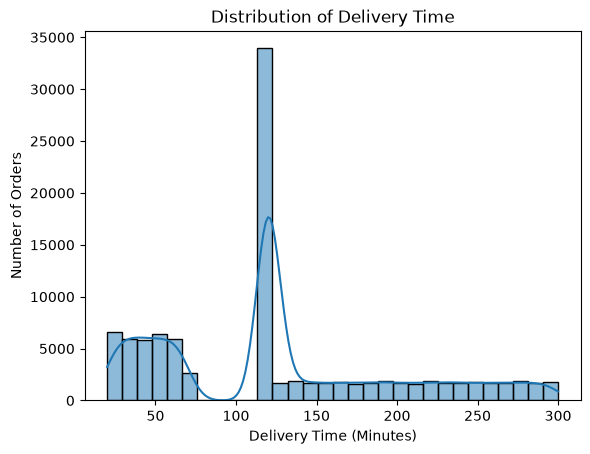

In [5]:
sns.histplot(df["Delivery_Time_Min"], bins=30, kde=True)

plt.title("Distribution of Delivery Time")
plt.xlabel("Delivery Time (Minutes)")
plt.ylabel("Number of Orders")

plt.show()

### Delivery Time Distribution
- Most deliveries take around 2 hours: A large number of deliveries are completed in about 120 minutes (2 hours).
- Some deliveries are faster or slower: Some deliveries take 20–70 minutes, while others take much longer, up to 300 minutes (5 hours).
- Delivery time is fairly balanced: The average is 125 minutes and the median is 120 minutes, so most deliveries are close to the 2-hour mark.

In [ ]:
# City-wise and cuisine-wise order analysis

In [6]:
df["City"].value_counts()

City
Hyderabad    16884
Bangalore    16732
Unknown      16726
Delhi        16695
Mumbai       16493
Chennai      16470
Name: count, dtype: int64

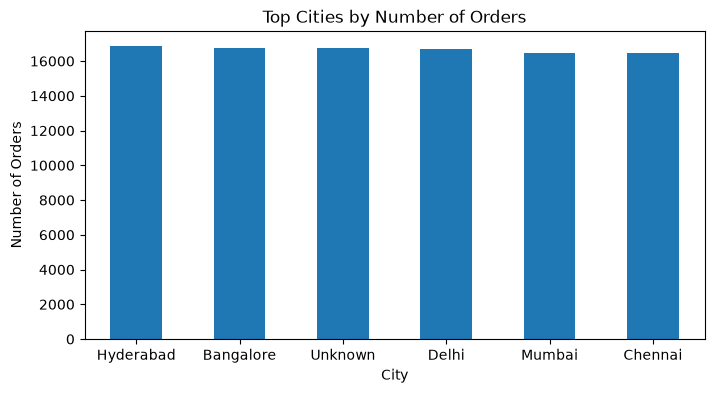

In [ ]:
plt.figure(figsize=(8,4))
df["City"].value_counts().plot(kind="bar")
plt.title("Top Cities by Number of Orders")
plt.xlabel("City")
plt.ylabel("Number of Orders")
plt.xticks(rotation=0)
plt.show()

### Observation

The number of orders is fairly similar across the cities. Hyderabad has the most orders, while Chennai has the fewest. The “Unknown” category represents orders where the city information was missing, so it is not an actual city.

In [16]:
df["Cuisine_Type"].value_counts()

Cuisine_Type
Unknown    16885
Indian     16685
Arabian    16658
Chinese    16651
Mexican    16602
Italian    16519
Name: count, dtype: int64

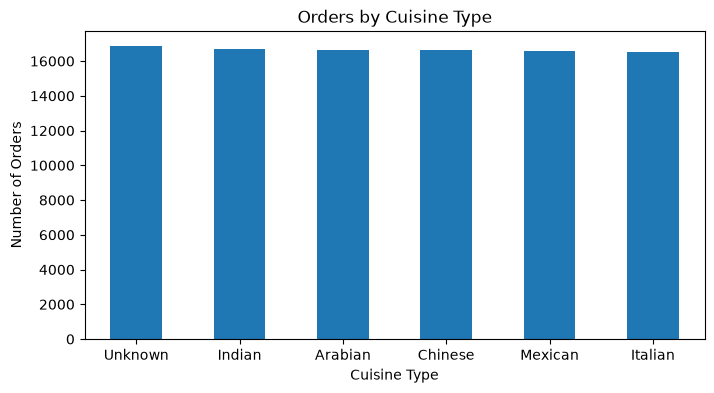

In [18]:
plt.figure(figsize=(8,4))
df["Cuisine_Type"].value_counts().plot(kind="bar")
plt.title("Orders by Cuisine Type")
plt.xlabel("Cuisine Type")
plt.ylabel("Number of Orders")
plt.xticks(rotation=0)
plt.show()

### Observation

The number of orders is fairly similar across the different cuisines. Indian cuisine has the most orders, while Italian has the fewest. The “Unknown” category represents orders where the cuisine information was missing, so it should not be considered as an actual cuisine preference.

## Weekend vs weekday demand

In [19]:
df["Order_Day"].value_counts()

Order_Day
Weekday    71370
Weekend    28630
Name: count, dtype: int64

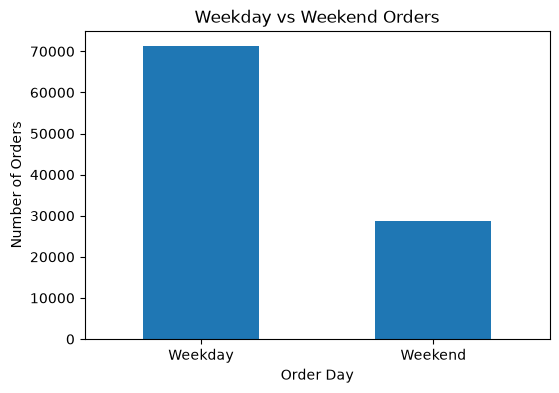

In [20]:
plt.figure(figsize=(6,4))
df["Order_Day"].value_counts().plot(kind="bar")
plt.title("Weekday vs Weekend Orders")
plt.xlabel("Order Day")
plt.ylabel("Number of Orders")
plt.xticks(rotation=0)
plt.show()

### Observation

The majority of orders are placed on weekdays, with 71,370 orders compared with 28,630 orders on weekends. This shows that weekday orders are substantially higher than weekend orders in the dataset.

## Distance vs Delivery Delay Relationship

In [23]:
df["Distance_km"].corr(df["Delivery_Time_Min"])

np.float64(0.002226501534623397)

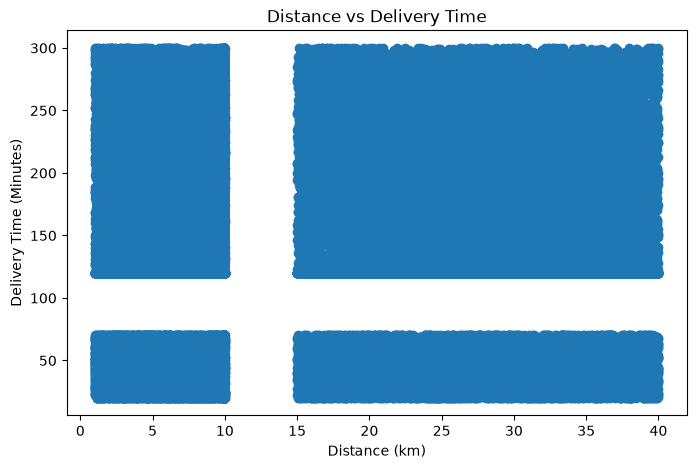

In [21]:
plt.figure(figsize=(8,5))
plt.scatter(df["Distance_km"], df["Delivery_Time_Min"])
plt.title("Distance vs Delivery Time")
plt.xlabel("Distance (km)")
plt.ylabel("Delivery Time (Minutes)")
plt.show()

In [22]:
df[["Distance_km", "Delivery_Time_Min"]].describe()

,Distance_km,Delivery_Time_Min
count,100000.000000,100000.000000
mean,14.280640,124.982030
std,10.454385,74.211956
min,1.000000,20.000000
25%,7.760000,58.000000
50%,9.970000,120.000000
75%,21.130000,165.000000
max,40.000000,300.000000


### Observation

- The correlation between distance and delivery time is very low (0.002). This means there is almost no clear connection between the two.
- Even though delivery distances range from 1 to 40 km and delivery times range from 20 to 300 minutes, a longer distance does not always mean a longer delivery time.

## Cancellation reasons analysis

In [24]:
#Cancellation Reasons Analysis
cancellation = df[
    (df["Order_Status"] == "Cancelled") &
    (df["Cancellation_Reason"] != "Unknown")
]["Cancellation_Reason"].value_counts()

cancellation

Cancellation_Reason
Late Delivery         3059
Customer Cancelled    2993
Restaurant Issue      2979
Name: count, dtype: int64

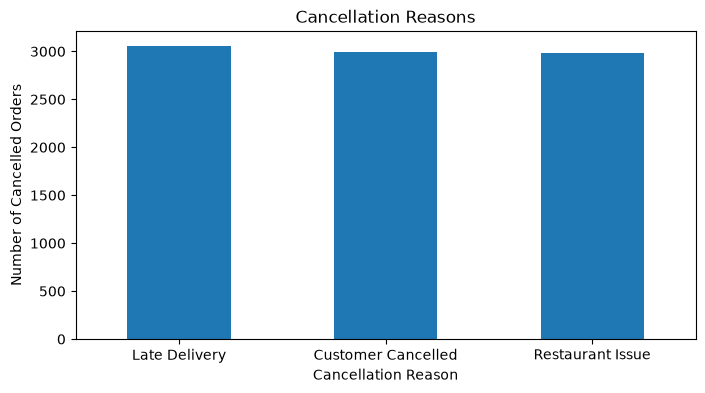

In [27]:
plt.figure(figsize=(8,4))

cancellation.plot(kind="bar")

plt.title("Cancellation Reasons")
plt.xlabel("Cancellation Reason")
plt.ylabel("Number of Cancelled Orders")
plt.xticks(rotation=0)

plt.show()

### Observation 

- Late Delivery is the most common reason for cancellation, with 3,059 orders. Customer Cancelled has 2,993 orders, and Restaurant Issue has 2,979 orders.
- The numbers are quite close, which means there is no single main reason for cancellations. All three reasons contribute almost equally.

## #Correlation analysis among numeric features

In [28]:
correlation = df.select_dtypes(include="number").corr()
correlation.round(2)

,Customer_Age,Delivery_Time_Min,Distance_km,Order_Value,Discount_Applied,Final_Amount,Delivery_Rating,Restaurant_Rating,Profit_Margin,Profit_Margin_Percentage
Customer_Age,1.00,-0.01,-0.0,-0.0,0.00,-0.00,-0.0,0.0,0.00,0.00
Delivery_Time_Min,-0.01,1.00,0.0,0.0,-0.00,0.00,0.0,0.0,-0.00,-0.00
Distance_km,-0.00,0.00,1.0,0.0,0.00,0.00,-0.0,0.0,0.00,0.00
Order_Value,-0.00,0.00,0.0,1.0,0.00,1.00,0.0,-0.0,-0.00,-0.00
Discount_Applied,0.00,-0.00,0.0,0.0,1.00,-0.07,0.0,0.0,0.01,0.01
Final_Amount,-0.00,0.00,0.0,1.0,-0.07,1.00,0.0,-0.0,-0.00,-0.00
Delivery_Rating,-0.00,0.00,-0.0,0.0,0.00,0.00,1.0,0.0,0.00,0.00
Restaurant_Rating,0.00,0.00,0.0,-0.0,0.00,-0.00,0.0,1.0,-0.00,-0.00
Profit_Margin,0.00,-0.00,0.0,-0.0,0.01,-0.00,0.0,-0.0,1.00,1.00
Profit_Margin_Percentage,0.00,-0.00,0.0,-0.0,0.01,-0.00,0.0,-0.0,1.00,1.00


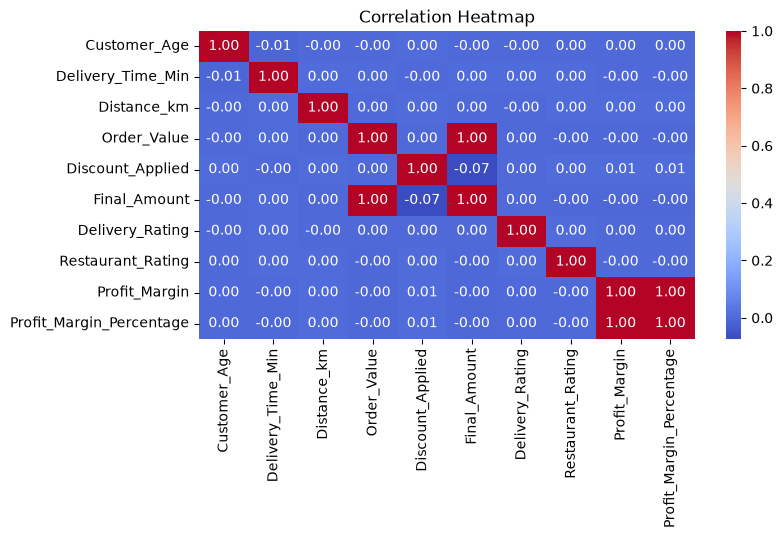

In [30]:
plt.figure(figsize=(8,4))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

### Observation

The heatmap shows that most numerical values do not have a strong relationship with each other.
- Order Value and Final Amount have a very strong relationship (1.00), which is expected because the final amount is calculated from the order value after applying the discount.
- Distance and Delivery Time have almost no relationship, meaning a longer distance does not necessarily mean a longer delivery time.
- Overall, most numerical variables have little or no clear linear relationship in this dataset.

### Exploratory Data Analysis (EDA) – Summary

The EDA helped us understand the main patterns in the food delivery data:
- Order Value: Most orders are around ₹1,100–₹1,300, while a smaller number of orders have higher values, going up to ₹5,000.
- Delivery Time: Most deliveries take around 120 minutes (2 hours), although some deliveries are faster and some take longer.
- City & Cuisine: The number of orders is fairly similar across the different cities and cuisine types. There is no major difference between the categories.
- Weekday vs Weekend: There are more orders on weekdays (71,370) compared to weekends (28,630).
- Distance vs Delivery Time: The correlation is 0.002, which means there is almost no clear relationship between delivery distance and delivery time.
- Cancellation Reasons: Among orders with a known cancellation reason, Late Delivery is the most common, followed by Customer Cancelled and Restaurant Issue.
- Correlation Analysis: Most numerical columns have little or no relationship with each other. The 1.00 correlation between Order Value and Final Amount is expected because the final amount is calculated using the order value and discount.